# Diabetes Progression Prediction using Neural Networks

This notebook performs regression on the diabetes dataset by:
1. Loading the standard diabetes dataset from scikit-learn
2. Training a multi-layer neural network with SELU activations using PyTorch
3. Visualising prediction accuracy and training progress
4. Comparing the neural network against pseudo-inverse (linear) regression

## Imports

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

## Load the Dataset

The diabetes dataset has 442 patients described by 10 normalised physiological
features. The regression target is a quantitative measure of disease progression
one year after baseline.

In [2]:
X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=16, shuffle=True)

## Define the Neural Network

Three hidden layers of decreasing width (20 → 10 → 5) with SELU activations.
SELU is self-normalising — it keeps activations near zero mean and unit variance
without explicit batch normalisation. The output is a single linear unit for regression.

In [3]:
net = nn.Sequential(
    nn.Linear(X_train.shape[1], 20),
    nn.SELU(),
    nn.Linear(20, 10),
    nn.SELU(),
    nn.Linear(10, 5),
    nn.SELU(),
    nn.Linear(5, 1),
)

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(net.parameters())

## Train the Model

MAE is tracked per epoch by accumulating the weighted batch loss.

In [4]:
n_epochs = 100
history_mae = []
n_train = len(X_train_t)

for epoch in range(n_epochs):
    net.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        out = net(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(y_batch)
    history_mae.append(epoch_loss / n_train)

## Results

Two plots side-by-side: predicted vs true values (a perfect model would lie on the red diagonal)
and training MAE over epochs.

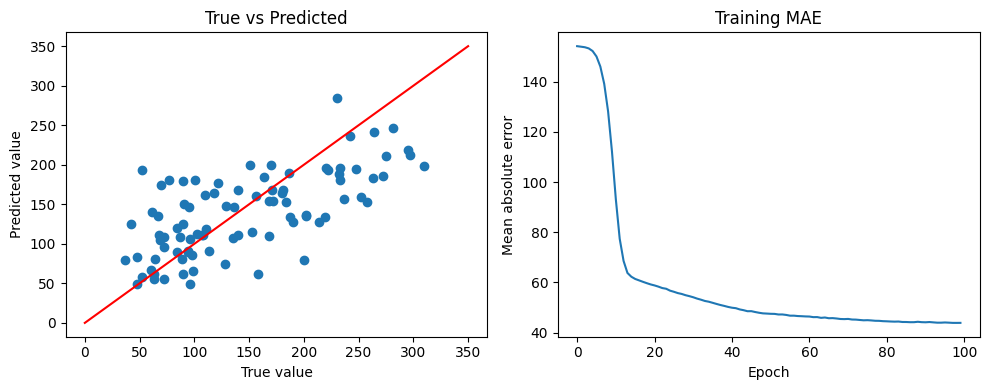

In [5]:
net.eval()
with torch.no_grad():
    y_pred = net(X_test_t).numpy()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(y_test, y_pred, 'o')
ax[0].plot([0, 350], [0, 350], 'r-')
ax[0].set_xlabel('True value')
ax[0].set_ylabel('Predicted value')
ax[0].set_title('True vs Predicted')

ax[1].plot(history_mae)
ax[1].set_title('Training MAE')
ax[1].set_ylabel('Mean absolute error')
ax[1].set_xlabel('Epoch')

plt.tight_layout()
plt.show()

## Comparison with Pseudo-Inverse Regression

The pseudo-inverse gives the optimal linear least-squares solution.
Comparing its MAE against the neural network shows how much non-linearity helps.

In [6]:
with torch.no_grad():
    mae_nn = criterion(net(X_test_t), y_test_t).item()

w = np.linalg.pinv(X_train) @ y_train
mae_pinv = np.mean(np.abs(y_test - X_test @ w))

print(f"MAE — Neural network:          {mae_nn:.2f}")
print(f"MAE — Pseudo-inverse (linear): {mae_pinv:.2f}")

MAE — Neural network:          42.91
MAE — Pseudo-inverse (linear): 157.78
